In [1]:
# import png
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [ ]:
path_original_SPACE= "//data/home/umang/Materials/QRBSA-data-augmentation/Quaternion_experiments/qrbsa_bs1_T10_loss2__Conv_min_angle_transformation/results/Test_model_best/Open_718/Dream3D/Open_718_Test_hr_x_normal_0_x4_SR_transformed.png"
path_transformed_SPACE= "/home/umang/a100_mount/Materials/QRBSA-data-augmentation/Quaternion_experiments/transposeConv_multipass_outerprod_kernel_3,4_extra_conv/results/Test_model_best/Open_718/Dream3D/Open_718_Test_hr_x_normal_0_x4_SR_0_qrbsa_1d_model_best_minimum_angle_transformation.png"
path = path_transformed_SPACE

img = plt.imread(path)

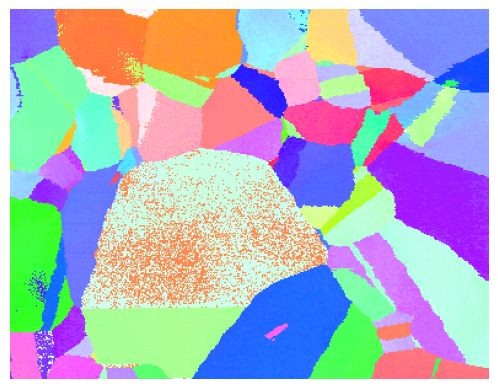

In [4]:
# show img 
plt.imshow(img)
plt.axis('off')
plt.show()

In [4]:
# run clustering algorithm on the img for blue vs green. only 2 clusters.
from sklearn.cluster import KMeans
def cluster_image(image, n_clusters=2):
    # Reshape the image to a 2D array of pixels
    pixels = image.reshape(-1, 3)
    
    # Apply KMeans clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=0)
    kmeans.fit(pixels)
    
    # Replace each pixel value with its cluster center
    clustered_pixels = kmeans.cluster_centers_[kmeans.labels_]
    
    # Reshape back to the original image shape
    clustered_image = clustered_pixels.reshape(image.shape).astype(np.uint8)
    
    return clustered_image


In [5]:
blue_grain =img[140:220, 90:220]

In [6]:
# Cluster the image
clustered_img = cluster_image(blue_grain, n_clusters=2)
# how many pixels in each cluster
unique, counts = np.unique(clustered_img.reshape(-1, clustered_img.shape[2]), axis=0, return_counts=True)
print("Cluster counts:", dict(zip(map(tuple, unique), counts)))

Cluster counts: {(0, 0, 0): 1113, (0, 0, 1): 9287}


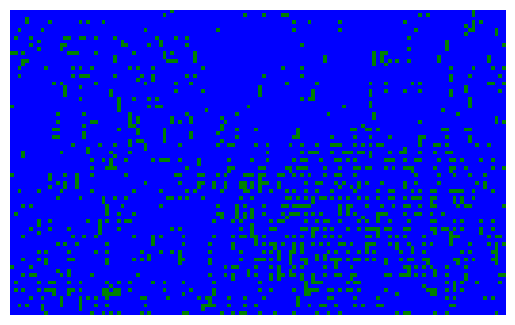

In [7]:
# Get cluster labels for each pixel
pixels = blue_grain.reshape(-1, 3)
kmeans = KMeans(n_clusters=2, random_state=0).fit(pixels)
labels = kmeans.labels_.reshape(img[140:220, 90:220].shape[:2])

# Display the clustered image using a colormap
cmap = mcolors.ListedColormap(['blue', 'green'])
plt.imshow(labels, cmap=cmap)
plt.axis('off')
plt.show()

# load fz quaternion data

In [8]:
import numpy as np
# load npy file 
npy_path= "/home/umang/a100_mount/Materials/QRBSA-data-augmentation/Quaternion_experiments/transposeConv_multipass_outerprod_kernel_3,4_extra_conv/sr_save/sr_save_qrbsa_1d_model_best_minimum_angle_transformation.npy"
data = np.load(npy_path)

In [9]:
# load original median indices
median_indices_path = "/home/umang/a100_mount/Materials/QRBSA-data-augmentation/Quaternion_experiments/transposeConv_multipass_outerprod_kernel_3,4_extra_conv/sr_save/sr_median_indices_qrbsa_1d_model_best_minimum_angle_transformation.npy"
median_indices = np.load(median_indices_path)

In [10]:
median_indices.shape, data.shape, img.shape

((1, 4, 304, 390), (100, 304, 390, 4), (301, 390, 3))

In [11]:
# trim data and median indices to fit img shape
median_indices= median_indices[..., :img.shape[0], :img.shape[1]]
data = data[:, :img.shape[0], :img.shape[1], :]
median_indices.shape, data.shape, img.shape

((1, 4, 301, 390), (100, 301, 390, 4), (301, 390, 3))

In [12]:
assert np.array_equal(median_indices[:, 0, ...], median_indices[:, 3, ...]), "Median indices should be the same for both dimensions"

In [13]:
# send 1st dim to last for median indices
median_indices = np.moveaxis(median_indices, 1, -1)
median_indices.shape

(1, 301, 390, 4)

In [14]:
# pool median quaternions from data using median indices
# median indices shpe (1, 301, 390, 4), data shape  (100, 301, 390, 4)

pooled_data = np.zeros((1, img.shape[0], img.shape[1], 4))
for i in range(median_indices.shape[1]):
    for j in range(median_indices.shape[2]):
        pooled_data[0, i, j, :] = data[median_indices[0,i,j,0], i,j,:]
pooled_data.shape

(1, 301, 390, 4)

In [15]:
pooled_data_sampled = pooled_data[:, 140:220, 90:220, :]
pooled_data_sampled.shape, blue_grain.shape

((1, 80, 130, 4), (80, 130, 3))

In [16]:
## get quaternions for label=0
quaternions_label_0 = pooled_data_sampled[0, labels == 0, :]
#print("Quaternions for label 0:", quaternions_label_0)

# get first 10 quaternions for label=0
quaternions_label_0_first_10 = quaternions_label_0[:10]
print("First 10 quaternions for label 0:", quaternions_label_0_first_10)

First 10 quaternions for label 0: [[-0.35491991  0.28599367 -0.18019956  0.87164658]
 [ 0.35929981  0.32735288  0.07369888  0.87081176]
 [ 0.36061129  0.32475135  0.07580052  0.8710624 ]
 [ 0.36028659  0.3229546   0.07345694  0.87206542]
 [-0.35839033  0.27933127 -0.16930109  0.87456745]
 [-0.35585028  0.28216347 -0.16234644  0.8760125 ]
 [ 0.36038378  0.32446939  0.07694571  0.87116194]
 [ 0.36063606  0.3240574   0.07729717  0.87117976]
 [-0.35617211  0.28194529 -0.16142388  0.87612247]
 [ 0.35437757  0.31967306  0.07527435  0.87553388]]


In [25]:
## get quaternions for label=1
quaternions_label_1 = pooled_data_sampled[0, labels == 1, :]
#print("Quaternions for label 1:", quaternions_label_1)

# get first 10 quaternions for label=1
quaternions_label_1_first_10 = quaternions_label_1[:10]
print("First 10 quaternions for label 1:", quaternions_label_1_first_10)

First 10 quaternions for label 1: [[-0.36029717  0.16237251  0.28745919  0.87246054]
 [ 0.3610214   0.31739119  0.08912142  0.8723433 ]
 [-0.35931829  0.29074946 -0.15381844  0.87332374]
 [-0.35532552  0.28189093 -0.16325945  0.87614375]
 [-0.35282633  0.28551501 -0.16996804  0.87470335]
 [-0.35509968  0.2816934  -0.16401586  0.87615764]
 [ 0.36308542  0.3090336   0.06119391  0.87688255]
 [ 0.35734054  0.31694371  0.08278975  0.87464219]
 [ 0.35922897  0.31832683  0.09065934  0.87258416]
 [ 0.35972512  0.31758815  0.09126799  0.87258554]]


## Now test on not fz reduced data. 

In [26]:
import numpy as np
# load npy file 
notfz_npy_path= "/home/umang/a100_mount/Materials/QRBSA-data-augmentation/Quaternion_experiments/transposeConv_multipass_outerprod_kernel_3,4_extra_conv/sr_save/sr_not_fz_reduced_qrbsa_1d_model_best_minimum_angle_transformation.npy"
not_fz_data = np.load(notfz_npy_path)

In [27]:
not_fz_data = not_fz_data[:, :img.shape[0], :img.shape[1], :]

In [28]:
# pool median quaternions from data using median indices
# median indices shpe (1, 301, 390, 4), data shape  (100, 301, 390, 4)

notfz_pooled_data = np.zeros((1, img.shape[0], img.shape[1], 4))
for i in range(median_indices.shape[1]):
    for j in range(median_indices.shape[2]):
        notfz_pooled_data[0, i, j, :] = not_fz_data[median_indices[0,i,j,0], i,j,:]
notfz_pooled_data.shape

(1, 301, 390, 4)

In [29]:
notfz_pooled_data_sampled = notfz_pooled_data[:, 140:220, 90:220, :]
notfz_pooled_data_sampled.shape, blue_grain.shape

((1, 80, 130, 4), (80, 130, 3))

In [30]:
## get quaternions for label=0
notfz_quaternions_label_0 = notfz_pooled_data_sampled[0, labels == 0, :]
#print("Quaternions for label 0:", quaternions_label_0)

# get first 10 quaternions for label=0
notfz_quaternions_label_0_first_10 = notfz_quaternions_label_0[:10]
print("First 10 not fz quaternions for label 0:", notfz_quaternions_label_0_first_10)

First 10 not fz quaternions for label 0: [[ 0.41411915 -0.37838662 -0.81857526  0.12354594]
 [ 0.48822877 -0.0552301  -0.7418828   0.45628187]
 [ 0.66953319 -0.56233507 -0.48462456 -0.02535682]
 [ 0.49142718 -0.05768363 -0.74092484  0.45409518]
 [ 0.87456745 -0.16930109 -0.27933127  0.35839033]
 [ 0.41991466 -0.36642042 -0.81895411  0.13682787]
 [ 0.49201098 -0.05468149 -0.73953468  0.45609659]
 [ 0.81658518 -0.41523063  0.13189174  0.37865195]
 [ 0.36766043  0.08522149 -0.31350935  0.87136388]
 [ 0.49275637 -0.06310447 -0.73715508  0.45805186]]


In [31]:
notfz_quaternions_label_0.shape

(9287, 4)

In [32]:
## get quaternions for label=1
notfz_quaternions_label_1 = notfz_pooled_data_sampled[0, labels == 1, :]
#print("Quaternions for label 1:", quaternions_label_1)

# get first 10 quaternions for label=1
notfz_quaternions_label_1_first_10 = notfz_quaternions_label_1[:10]
print("First 10 not fz quaternions for label 1:", notfz_quaternions_label_1_first_10)

First 10 not fz quaternions for label 1: [[ 0.08844963 -0.87169135 -0.36215419  0.31807905]
 [ 0.08912142 -0.8723433  -0.3610214   0.31739119]
 [ 0.50876707 -0.72629923  0.0484855   0.45966733]
 [ 0.0378339  -0.5564189  -0.48298433  0.67505038]
 [ 0.03319696 -0.55599135 -0.48868001  0.67153829]
 [ 0.5035603  -0.73551375  0.05190608  0.45028073]
 [ 0.80509776 -0.43487024  0.13297874  0.38081843]
 [ 0.08278975 -0.87464219 -0.35734054  0.31694371]
 [ 0.68111604 -0.55290437 -0.47910431 -0.02892218]
 [ 0.6815474  -0.55247498 -0.47893283 -0.02979534]]
